# 1. Creating the Baseline Model
<hr>

1.1 Loading data & filtering out countries with less than 20 entries

In [50]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def load_data(address):
    df = pd.DataFrame(pd.read_csv(address))
    return df
df = load_data('data/cost-of-living_v2.csv')
min_samples = 20
valid_country_names = df['country'].value_counts()
valid_country_names = valid_country_names[valid_country_names >= min_samples].index
filtered_df = df[df['country'].isin(valid_country_names)]
print("Number of countries:", filtered_df['country'])
filtered_df['country'].value_counts()

Number of countries: 0       South Korea
1             China
2             China
3             India
4             India
           ...     
4949      Australia
4951      Australia
4952      Australia
4953         Mexico
4954         Canada
Name: country, Length: 4174, dtype: str


country
United States      1073
Italy               186
India               167
Brazil              164
United Kingdom      160
Germany             147
Russia              139
Canada              120
France              113
China               104
Spain                88
Mexico               87
Philippines          77
Japan                75
Poland               66
Australia            64
Turkey               61
Netherlands          55
Romania              53
Portugal             52
Ukraine              45
Hungary              44
Czech Republic       44
Switzerland          43
Indonesia            40
Pakistan             39
Belgium              39
Thailand             37
Iran                 37
Greece               36
South Africa         34
Algeria              34
Serbia               34
Israel               34
Slovakia             34
Malta                34
Morocco              32
Nigeria              31
Bulgaria             30
Sweden               30
South Korea          29
Argentin

1.2 Replacing feature names with the items they represent

In [51]:
feature_names = [
    'Milk', 'Bread', 'Rice', 'Eggs', 'Local Cheese',
    'Chicken Fillets', 'Beef Round', 'Apples', 'Banana',
    'Oranges', 'Tomato', 'Potato', 'Onion', 'Lettuce',
    'Water', 'Bottle of Wine', 'Domestic Beer', 'Imported Beer'
]
grocery_cols = [f'x{i}' for i in range(9, 27)]
identity_cols = ['city', 'country']

grocery_df = filtered_df[identity_cols + grocery_cols].copy()
grocery_cols_features = {f'x{i}': name for i, name in zip(range(9, 27), feature_names)}
grocery_df = grocery_df.rename(columns=grocery_cols_features)
grocery_df.head()

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,Banana,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer
0,Seoul,South Korea,2.20,2.85,3.53,4.04,11.54,10.58,41.61,6.77,3.71,6.50,6.19,3.84,2.92,2.45,1.05,15.36,2.12,2.36
1,Shanghai,China,2.74,2.61,1.22,2.22,18.35,4.86,13.12,2.26,1.60,2.19,1.53,0.84,1.04,0.83,0.64,14.24,0.94,1.97
2,Guangzhou,China,1.91,1.63,1.03,1.71,9.00,3.77,11.75,2.02,1.44,1.82,1.31,0.74,1.00,0.49,0.51,11.39,0.95,2.26
3,Mumbai,India,0.75,0.50,0.83,0.95,5.88,3.69,5.95,2.09,0.67,1.34,0.59,0.44,0.44,0.65,0.35,9.83,2.27,3.61
4,Delhi,India,0.73,0.50,0.85,1.02,4.36,3.81,5.71,1.79,0.75,1.03,0.61,0.37,0.41,0.70,0.36,9.83,1.54,2.49


In [52]:
grocery_df.shape

(4174, 20)

1.3 Imputing Missing Values

In [53]:
def count_the_missing_values_of_each_column(df):
    missing_values_series = df.isnull().sum()
    return missing_values_series

missing_values_series = count_the_missing_values_of_each_column(grocery_df)
print(missing_values_series)

city                 0
country              0
Milk               321
Bread              353
Rice               277
Eggs               455
Local Cheese       381
Chicken Fillets    493
Beef Round         486
Apples             295
Banana             303
Oranges            355
Tomato             397
Potato             363
Onion              352
Lettuce            387
Water              313
Bottle of Wine     360
Domestic Beer      612
Imported Beer      539
dtype: int64


In [54]:
grocery_df_imputed = grocery_df.fillna(grocery_df.mean(numeric_only=True))
missing_values_series = count_the_missing_values_of_each_column(grocery_df_imputed)
print(missing_values_series)

city               0
country            0
Milk               0
Bread              0
Rice               0
Eggs               0
Local Cheese       0
Chicken Fillets    0
Beef Round         0
Apples             0
Banana             0
Oranges            0
Tomato             0
Potato             0
Onion              0
Lettuce            0
Water              0
Bottle of Wine     0
Domestic Beer      0
Imported Beer      0
dtype: int64


# 2. Ablation Tests
<hr>

2.1 Creating the grocery ppp/grocery price index using the USA as a baseline

In [55]:
usd_df = grocery_df_imputed.copy()
usd_df['Total_Basket'] = usd_df[feature_names].sum(axis=1)
usa_baseline = usd_df[usd_df['country'] == 'United States']['Total_Basket'].median()
usd_df['Grocery_Price_Index'] = usd_df['Total_Basket'] / usa_baseline
grocery_df_imputed['Grocery_Price_Index'] = usd_df['Grocery_Price_Index']
grocery_df_imputed.head()

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,...,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer,Grocery_Price_Index
0,Seoul,South Korea,2.20,2.85,3.53,4.04,11.54,10.58,41.61,6.77,...,6.50,6.19,3.84,2.92,2.45,1.05,15.36,2.12,2.36,1.514960
1,Shanghai,China,2.74,2.61,1.22,2.22,18.35,4.86,13.12,2.26,...,2.19,1.53,0.84,1.04,0.83,0.64,14.24,0.94,1.97,0.855540
2,Guangzhou,China,1.91,1.63,1.03,1.71,9.00,3.77,11.75,2.02,...,1.82,1.31,0.74,1.00,0.49,0.51,11.39,0.95,2.26,0.639668
3,Mumbai,India,0.75,0.50,0.83,0.95,5.88,3.69,5.95,2.09,...,1.34,0.59,0.44,0.44,0.65,0.35,9.83,2.27,3.61,0.477209
4,Delhi,India,0.73,0.50,0.85,1.02,4.36,3.81,5.71,1.79,...,1.03,0.61,0.37,0.41,0.70,0.36,9.83,1.54,2.49,0.430809


2.2 Splitting the dataset into 3 copies with different feature ablations

In [56]:
grocery_items = feature_names # The 18 items
macro_signal = ['Grocery_Price_Index'] # Macro

X_macro = grocery_df_imputed[macro_signal]
X_fingerprint = grocery_df_imputed[grocery_items]
X_full = grocery_df_imputed[grocery_items + macro_signal]
y = grocery_df_imputed['country']

2.3 Running the tests

In [57]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd


top_countries = y.value_counts().head(10).index
results = {}
ablation_report = {}
models = {}
feature_sets = {
    "Macro Only (Index)": X_macro,
    "Fingerprint Only (Items)": X_fingerprint,
    "Full Model (Both)": X_full
}


for name, X_subset in feature_sets.items():
    #Split trainset and testset
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y, test_size=0.2, random_state=42, stratify=y
    )

    #StandardScaler
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)

    # Train the same model family
    abl_model = LogisticRegression(max_iter=1000, random_state=42)
    abl_model.fit(X_train_scaled, y_train_sub)
    y_pred = abl_model.predict(X_test_scaled)


    results[name] = {
        "Y Pred": y_pred,
        "Y Test": y_test_sub,
        "Accuracy": accuracy_score(y_test_sub, y_pred),
        "Macro F1": f1_score(y_test_sub, y_pred, average='macro')
    }
    ablation_report[name] = {
        "Accuracy": accuracy_score(y_test_sub, y_pred),
        "Macro F1": f1_score(y_test_sub, y_pred, average='macro')
    }


ablation_report = pd.DataFrame(ablation_report).T
print(ablation_report)

                          Accuracy  Macro F1
Macro Only (Index)        0.328144  0.040389
Fingerprint Only (Items)  0.826347  0.768405
Full Model (Both)         0.827545  0.769363


# 3. Analysis
<hr>

3.1 Confusion Matrices

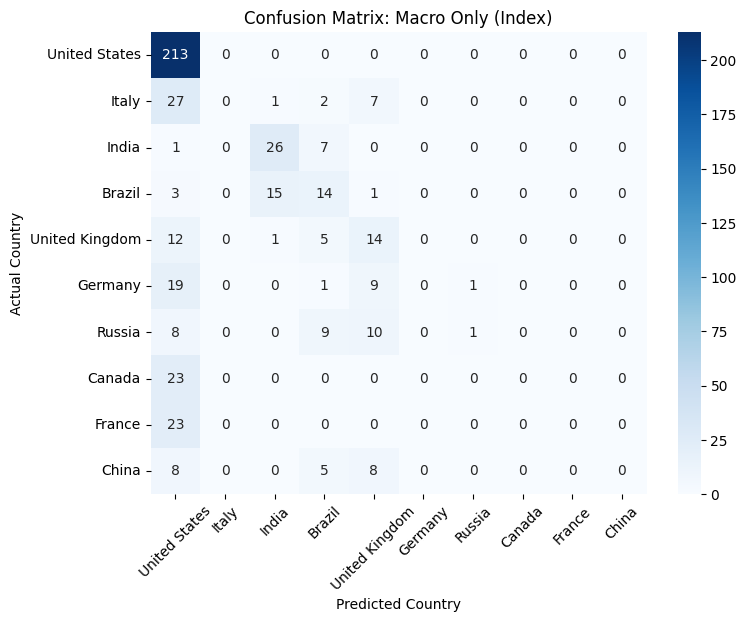

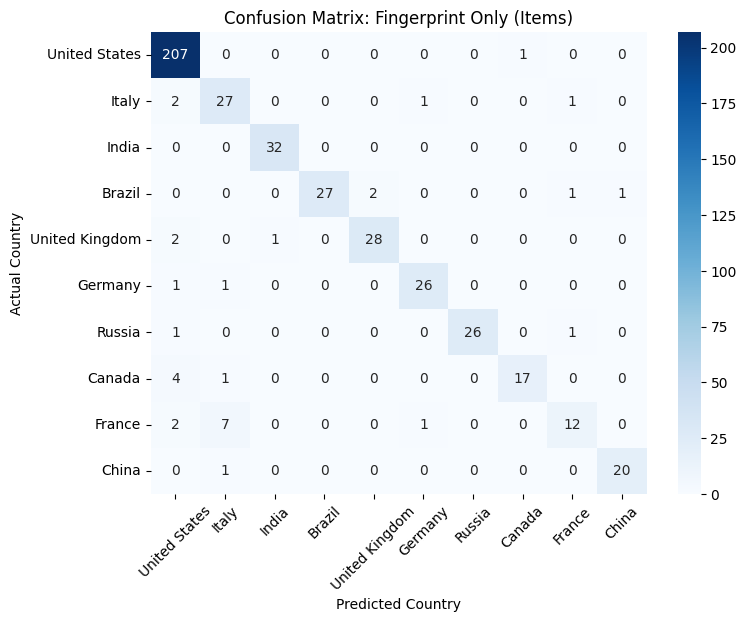

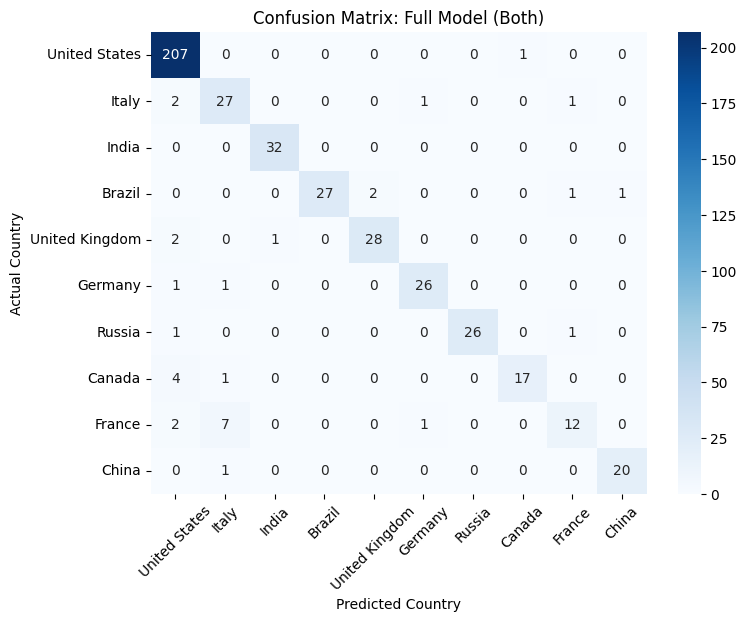

In [58]:
for name, X_subset in feature_sets.items():
    mask = y_test_sub.isin(top_countries)
    cm = confusion_matrix(
        results[name]['Y Test'][mask],
        results[name]['Y Pred'][mask],
        labels=top_countries
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=top_countries,
        yticklabels=top_countries,
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual Country')
    plt.xlabel('Predicted Country')
    plt.xticks(rotation=45)
    plt.show()
    print("\n")

3.2 Per-Country Confusion Matrices

--- Results for: United States using Macro Only (Index) ---
Accuracy: 0.7029940119760479
Macro F1: 0.6915257469045321


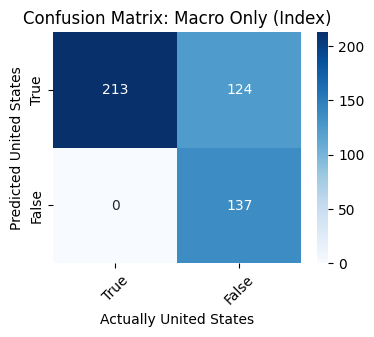

--- Results for: Italy using Macro Only (Index) ---
Accuracy: 0.9556886227544911
Macro F1: 0.488671157379057


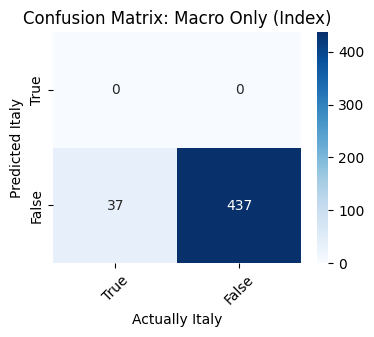

--- Results for: India using Macro Only (Index) ---
Accuracy: 0.8491017964071856
Macro F1: 0.6038422146579511


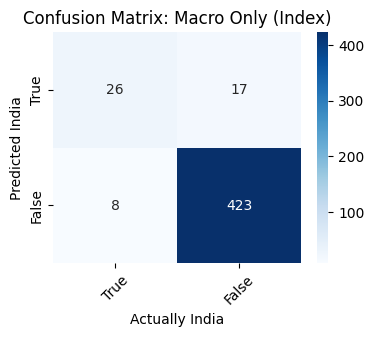

--- Results for: Brazil using Macro Only (Index) ---
Accuracy: 0.8323353293413174
Macro F1: 0.536728806036396


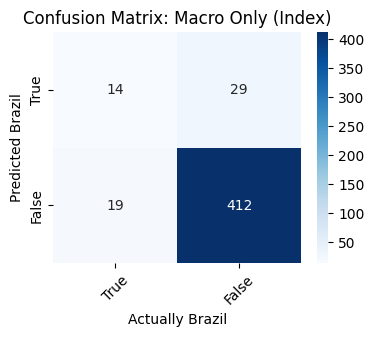

--- Results for: United Kingdom using Macro Only (Index) ---
Accuracy: 0.9005988023952096
Macro F1: 0.5995064981594809


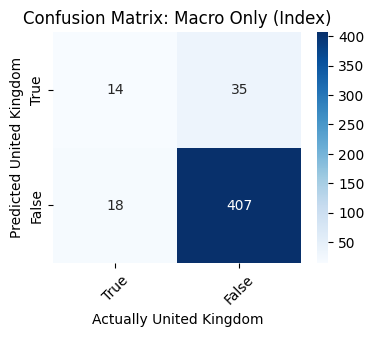

--- Results for: Germany using Macro Only (Index) ---
Accuracy: 0.9640718562874252
Macro F1: 0.49085365853658536


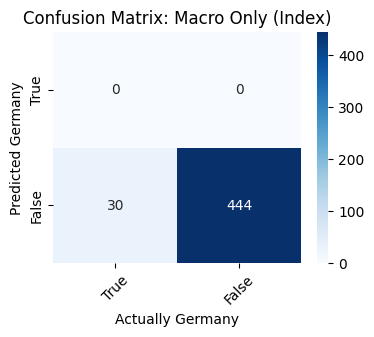

--- Results for: Russia using Macro Only (Index) ---
Accuracy: 0.9604790419161676
Macro F1: 0.5184796854521625


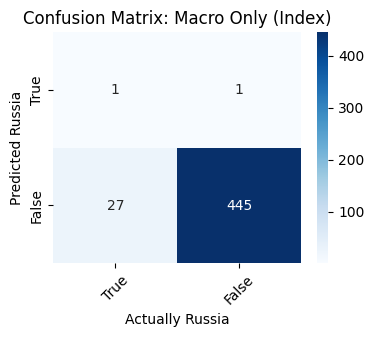

--- Results for: Canada using Macro Only (Index) ---
Accuracy: 0.9712574850299401
Macro F1: 0.49270959902794653


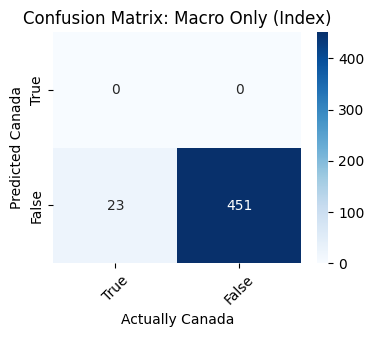

--- Results for: France using Macro Only (Index) ---
Accuracy: 0.9724550898203593
Macro F1: 0.4930176077717061


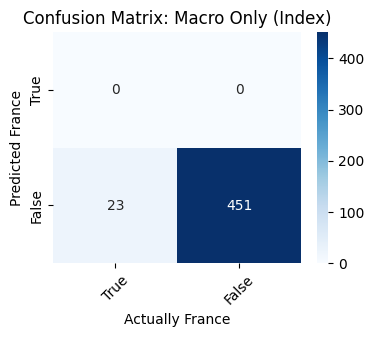

--- Results for: China using Macro Only (Index) ---
Accuracy: 0.9748502994011976
Macro F1: 0.49363250454821106


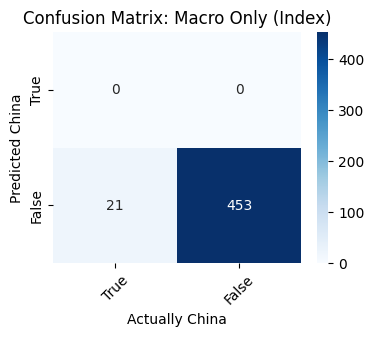

--- Results for: United States using Full Model (Both) ---
Accuracy: 0.9532934131736527
Macro F1: 0.9409306349888718


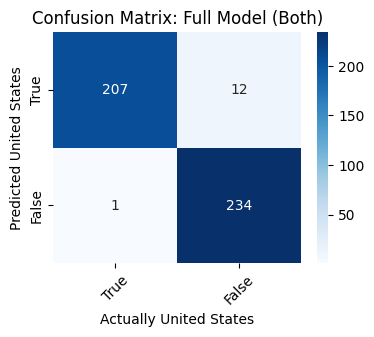

--- Results for: Italy using Full Model (Both) ---
Accuracy: 0.9688622754491018
Macro F1: 0.8293238993710692


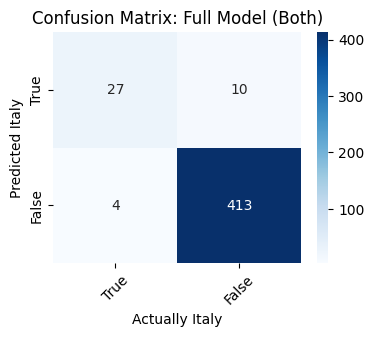

--- Results for: India using Full Model (Both) ---
Accuracy: 0.9952095808383233
Macro F1: 0.969339795843431


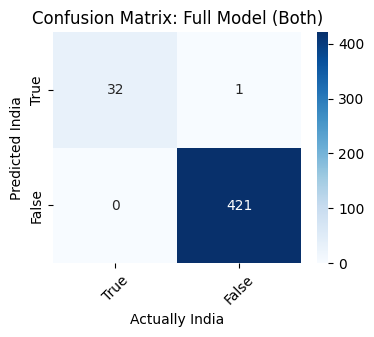

--- Results for: Brazil using Full Model (Both) ---
Accuracy: 0.9868263473053892
Macro F1: 0.9119578241073568


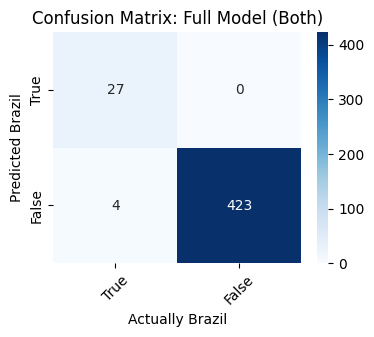

--- Results for: United Kingdom using Full Model (Both) ---
Accuracy: 0.9868263473053892
Macro F1: 0.91447938101135


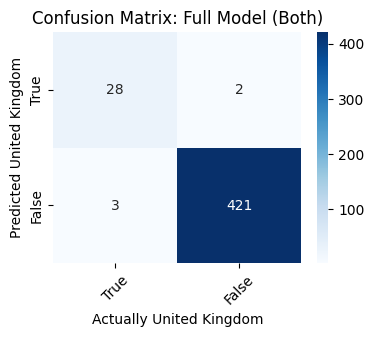

--- Results for: Germany using Full Model (Both) ---
Accuracy: 0.9868263473053892
Macro F1: 0.9092758862516175


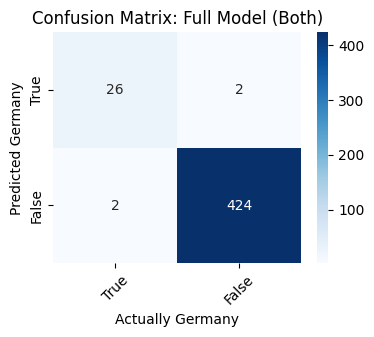

--- Results for: Russia using Full Model (Both) ---
Accuracy: 0.9940119760479041
Macro F1: 0.9545904438716133


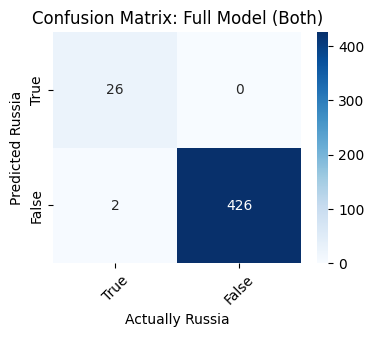

--- Results for: Canada using Full Model (Both) ---
Accuracy: 0.9892215568862276
Macro F1: 0.8925830105344406


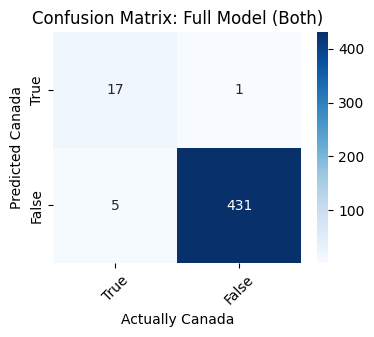

--- Results for: France using Full Model (Both) ---
Accuracy: 0.9736526946107784
Macro F1: 0.754096166202613


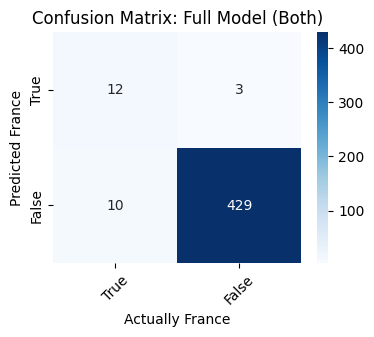

--- Results for: China using Full Model (Both) ---
Accuracy: 0.9964071856287425
Macro F1: 0.9641943368448136


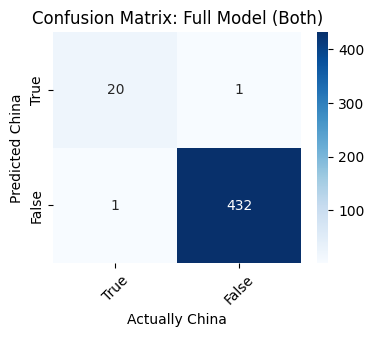

In [59]:
per_country_results = {}
feature_sets = {
    "Macro Only (Index)": X_macro,
    "Full Model (Both)": X_full
}

for name, X_subset in feature_sets.items():
    cm = confusion_matrix(
        results[name]['Y Test'][mask],
        results[name]['Y Pred'][mask],
        labels=top_countries
    )
    per_country_results[name] = {}
    i = 0
    for country in top_countries:
        test = [x == country for x in results[name]['Y Test']]
        pred = [x == country for x in results[name]['Y Pred']]
        country_cm = np.zeros((2, 2)).astype(int)
        country_cm[0][0] = cm[i][i]
        country_cm[0][1] = np.sum(cm[:, i]) - country_cm[0][0]
        country_cm[1][0] = np.sum(cm[i, :]) - country_cm[0][0]
        country_cm[1][1] = ((np.sum(cm) - country_cm[0][0]) - country_cm[0][1]) - country_cm[1][0]
        i += 1

        per_country_results[name].update({
            f"{country} Accuracy": accuracy_score(test, pred),
            f"{country} Macro F1": f1_score(test, pred, average='macro'),
            f"{country} True Positives": country_cm[0][0],
            f"{country} False Positives": country_cm[0][1],
            f"{country} False Negatives": country_cm[1][0],
            f"{country} True Negatives": country_cm[1][1]
        })
        print(f"--- Results for: {country} using {name} ---")
        print("Accuracy:", accuracy_score(test, pred))
        print("Macro F1:", f1_score(test, pred, average='macro'))
        plt.figure(figsize=(4, 3))
        sns.heatmap(
            country_cm,
            annot=True,
            fmt='d',
            xticklabels=['True', 'False'],
            yticklabels=['True', 'False'],
            cmap='Blues'
        )
        plt.title(f"Confusion Matrix: {name}")
        plt.xlabel(f'Actually {country}')
        plt.ylabel(f'Predicted {country}')
        plt.xticks(rotation=45)
        plt.show()


3.3 Per-Country F1 Score Comparison

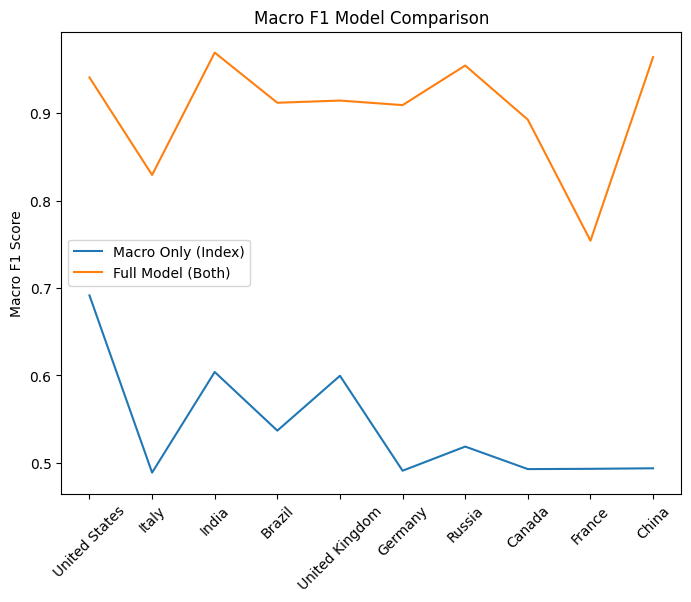

In [60]:
f1s = []
f3s = []
for country in top_countries:
    f1s.append(per_country_results["Macro Only (Index)"][f"{country} Macro F1"])
    f3s.append(per_country_results["Full Model (Both)"][f"{country} Macro F1"])


plt.figure(figsize=(8, 6))
plt.plot(top_countries, f1s, label="Macro Only (Index)")
plt.plot(top_countries, f3s, label="Full Model (Both)")
plt.xticks(rotation=45)
plt.title(f"Macro F1 Model Comparison")
plt.ylabel('Macro F1 Score')
plt.legend()
plt.show()

3.5 Error Analysis

In [61]:
per_country_results = {}

feature_sets = {
    "Macro Only (Index)": X_macro,
    #"Fingerprint Only (Items)": X_fingerprint,
    "Full Model (Both)": X_full
}

for name, X_subset in feature_sets.items():
    # ERROR RATE SELECTION

    error_df = pd.DataFrame({
        'true': results[name]['Y Test'],
        'pred': results[name]['Y Pred']
    })

    error_df['error'] = (error_df['true'] != error_df['pred'])

    error_rate = (
        error_df.groupby('true')['error']
        .mean()
        .sort_values(ascending=False)
    )

    top_countries = error_rate.head(10).index

    print(f"\n===== Top Error Countries ({name}) =====")
    print(error_rate.head(10))
    print("\n")


    # Confusion Pairs
    for country in top_countries:
        test = (results[name]['Y Test'] == country)
        pred = (results[name]['Y Pred'] == country)

        falsePos = results[name]['Y Pred'][test & (results[name]['Y Pred'] != country)]
        falseNeg = results[name]['Y Test'][pred & (results[name]['Y Test'] != country)]

        print(f"--- Results for: {country} using {name} ---")
        print("Countries Most Similar:")

        combined = pd.concat([pd.Series(falsePos), pd.Series(falseNeg)])
        print(combined.value_counts().head())

        print("\n")


    # FP / FN analysis

    fps = []
    fns = []

    per_country_results[name] = {}

    for i, country in enumerate(top_countries):

        TP = cm[i][i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP
        TN = np.sum(cm) - TP - FP - FN

        per_country_results[name].update({
            f"{country} Accuracy": TP / (TP + FN) if (TP + FN) > 0 else 0,
            f"{country} Macro F1": f1_score(
                (y_test_sub == country),
                (y_pred == country),
                average='macro'
            ),
            f"{country} TP": TP,
            f"{country} FP": FP,
            f"{country} FN": FN,
            f"{country} TN": TN
        })

        total_errors = FP + FN
        if total_errors == 0:
            fps.append(0)
            fns.append(0)
        else:
            fps.append(FP / total_errors)
            fns.append(FN / total_errors)


===== Top Error Countries (Macro Only (Index)) =====
true
Algeria      1.0
Argentina    1.0
Australia    1.0
Belgium      1.0
Bulgaria     1.0
Canada       1.0
Chile        1.0
China        1.0
Greece       1.0
Colombia     1.0
Name: error, dtype: float64


--- Results for: Algeria using Macro Only (Index) ---
Countries Most Similar:
Brazil            4
India             2
United Kingdom    1
Name: count, dtype: int64


--- Results for: Argentina using Macro Only (Index) ---
Countries Most Similar:
India            2
United States    2
Brazil           1
Name: count, dtype: int64


--- Results for: Australia using Macro Only (Index) ---
Countries Most Similar:
United States    13
Name: count, dtype: int64


--- Results for: Belgium using Macro Only (Index) ---
Countries Most Similar:
United States    8
Name: count, dtype: int64


--- Results for: Bulgaria using Macro Only (Index) ---
Countries Most Similar:
Brazil    3
India     3
Name: count, dtype: int64


--- Results for: Canada us

# 4. Robustness Check
<hr>

In [62]:
for seed in [42, 0, 123, 85]:
    #Split trainset and testset
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_full, y, test_size=0.2, random_state=seed, stratify=y
    )

    #StandardScaler
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)

    # Train the same model family
    abl_model = LogisticRegression(max_iter=1000, random_state=seed)
    abl_model.fit(X_train_scaled, y_train_sub)
    y_pred = abl_model.predict(X_test_scaled)


    print('seed =', seed)
    print("Accuracy:", accuracy_score(y_test_sub, y_pred))
    print("Macro F1:", f1_score(y_test_sub, y_pred, average='macro'))

seed = 42
Accuracy: 0.8275449101796407
Macro F1: 0.7693631677442332
seed = 0
Accuracy: 0.8263473053892215
Macro F1: 0.7807161767959029
seed = 123
Accuracy: 0.8035928143712575
Macro F1: 0.7342263445727278
seed = 85
Accuracy: 0.8323353293413174
Macro F1: 0.7740649640659402
